# Notebook 06: Baseline Comparison : EfficientNet-B0 vs ConvNeXt-Nano vs Swin-T
**Goal:** Load results JSONs from NB03–05 and compare all three backbones 
under identical ABMIL pipeline conditions. No training happens here. 
*This notebook is for analysis only*.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

OUT = Path("/kaggle/working")
print("Output dir:", OUT)

Output dir: /kaggle/working


## 1. Load Results
Verify all three results JSONs are accessible before loading.

In [2]:
# Paths to results JSONs
NB03_JSON = Path("/kaggle/input/notebooks/mfjmrizvi/03-efficientnet-b0/efficientnet_b0_results.json")
NB04_JSON = Path("/kaggle/input/notebooks/mfjmrizvi/04-convnext-nano/convnext_nano_results.json")
NB05_JSON = Path("/kaggle/input/notebooks/mfjmrizvi/05-swint/swin_t_results.json")

for p in [NB03_JSON, NB04_JSON, NB05_JSON]:
    print(f"{'✓' if p.exists() else '✗ MISSING'} {p.name}")

✓ efficientnet_b0_results.json
✓ convnext_nano_results.json
✓ swin_t_results.json


## 2. Parse and Inspect Results
Load all three JSONs into a unified dict and print full metrics 
for each model to confirm correct loading before comparison.

In [3]:
# Load results
with open(NB03_JSON) as f: nb03 = json.load(f)
with open(NB04_JSON) as f: nb04 = json.load(f)
with open(NB05_JSON) as f: nb05 = json.load(f)

results = {
    "EfficientNet-B0" : nb03,
    "ConvNeXt-Nano"   : nb04,
    "Swin-T"          : nb05,
}

print("Loaded results for:", list(results.keys()))

Loaded results for: ['EfficientNet-B0', 'ConvNeXt-Nano', 'Swin-T']


In [4]:
# Print full results for each model to confirm load
for name, r in results.items():
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  FEAT_DIM          : {r['feat_dim']}")
    print(f"  Optimal threshold : {r['optimal_threshold']:.4f}")
    print(f"\n  Stage 1 patch metrics:")
    for k, v in r["stage1_metrics"].items():
        print(f"    {k:25s}: {v:.4f}")
    print(f"\n  Val set (calibrated threshold):")
    for k, v in r["val_metrics_cal"].items():
        print(f"    {k:15s}: {v:.4f}")
    print(f"\n  Test set (calibrated threshold):")
    for k, v in r["test_metrics"].items():
        print(f"    {k:15s}: {v:.4f}")


  EfficientNet-B0
  FEAT_DIM          : 1280
  Optimal threshold : 0.9884

  Stage 1 patch metrics:
    patch_auc                : 0.8094
    patch_f1                 : 0.6804
    patch_sensitivity        : 0.5671
    patch_specificity        : 0.9420

  Val set (calibrated threshold):
    threshold      : 0.9884
    auc            : 0.9895
    f1             : 0.9527
    sensitivity    : 0.9097
    specificity    : 1.0000
    fpr            : 0.0000
    ece            : 0.0168

  Test set (calibrated threshold):
    threshold      : 0.9884
    auc            : 0.9996
    f1             : 0.9831
    sensitivity    : 0.9864
    specificity    : 0.9870
    fpr            : 0.0130
    ece            : 0.0159

  ConvNeXt-Nano
  FEAT_DIM          : 640
  Optimal threshold : 0.5811

  Stage 1 patch metrics:
    patch_auc                : 0.7250
    patch_f1                 : 0.5770
    patch_sensitivity        : 0.4497
    patch_specificity        : 0.9367

  Val set (calibrated threshold):

## 3. Unified Comparison Table
All metrics across Stage 1, val, and test sets side by side. 
Calibrated threshold is used throughout and not the default 0.5.

In [5]:
# Build unified comparison table and print it
models     = list(results.keys())
col_width  = 20

# Metrics to compare and where they live in the JSON
row_defs = [
    ("FEAT_DIM",            lambda r: r["feat_dim"],                               "d"),
    ("Optimal threshold",   lambda r: r["optimal_threshold"],                      ".4f"),
    ("S1 patch AUC",        lambda r: r["stage1_metrics"]["patch_auc"],            ".4f"),
    ("S1 patch F1",         lambda r: r["stage1_metrics"]["patch_f1"],             ".4f"),
    ("S1 patch sensitivity",lambda r: r["stage1_metrics"]["patch_sensitivity"],    ".4f"),
    ("S1 patch specificity",lambda r: r["stage1_metrics"]["patch_specificity"],    ".4f"),
    ("Val AUC",             lambda r: r["val_metrics_cal"]["auc"],                 ".4f"),
    ("Val F1",              lambda r: r["val_metrics_cal"]["f1"],                  ".4f"),
    ("Val sensitivity",     lambda r: r["val_metrics_cal"]["sensitivity"],         ".4f"),
    ("Val FPR",             lambda r: r["val_metrics_cal"]["fpr"],                 ".4f"),
    ("Val ECE",             lambda r: r["val_metrics_cal"]["ece"],                 ".4f"),
    ("Test AUC",            lambda r: r["test_metrics"]["auc"],                    ".4f"),
    ("Test F1",             lambda r: r["test_metrics"]["f1"],                     ".4f"),
    ("Test sensitivity",    lambda r: r["test_metrics"]["sensitivity"],            ".4f"),
    ("Test specificity",    lambda r: r["test_metrics"]["specificity"],            ".4f"),
    ("Test FPR",            lambda r: r["test_metrics"]["fpr"],                    ".4f"),
    ("Test ECE",            lambda r: r["test_metrics"]["ece"],                    ".4f"),
]

# Header
header = f"{'Metric':<28}" + "".join(f"{m:>{col_width}}" for m in models)
print("\n" + "=" * (28 + col_width * len(models)))
print(header)
print("=" * (28 + col_width * len(models)))

for label, extractor, fmt in row_defs:
    row = f"{label:<28}"
    for name in models:
        val = extractor(results[name])
        row += f"{format(val, fmt):>{col_width}}"
    print(row)

print("=" * (28 + col_width * len(models)))


Metric                           EfficientNet-B0       ConvNeXt-Nano              Swin-T
FEAT_DIM                                    1280                 640                 768
Optimal threshold                         0.9884              0.5811              0.3643
S1 patch AUC                              0.8094              0.7250              0.8087
S1 patch F1                               0.6804              0.5770              0.6615
S1 patch sensitivity                      0.5671              0.4497              0.6494
S1 patch specificity                      0.9420              0.9367              0.8177
Val AUC                                   0.9895              0.9663              0.9943
Val F1                                    0.9527              0.9455              0.9714
Val sensitivity                           0.9097              0.9028              0.9444
Val FPR                                   0.0000              0.0088              0.0000
Val ECE             

## 4. Test Set Bar Chart
Visual comparison of the four primary test metrics. Y-axis starts 
at 0.88 to make differences visible as all three models perform 
in a narrow high range.

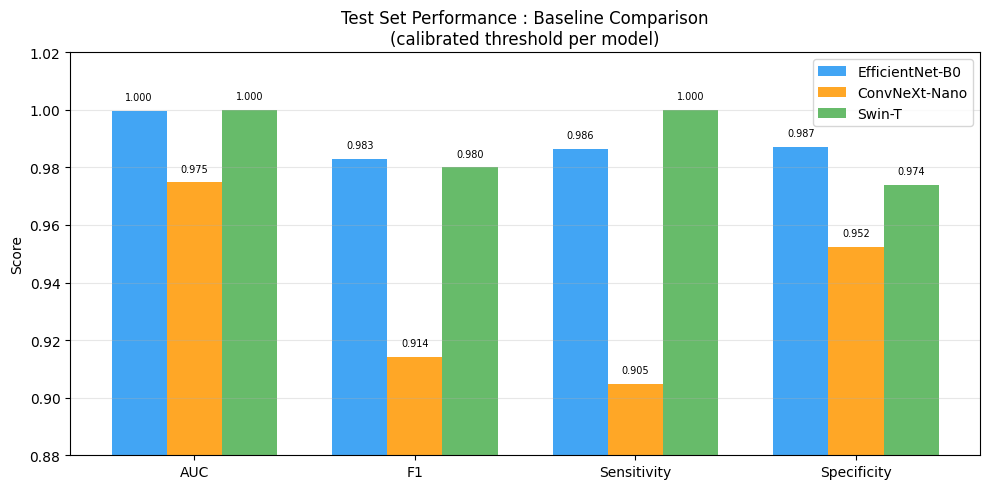

Saved nb06_test_bar_chart.png


In [6]:
# Bar chart comparison for test set metrics
test_metrics_to_plot = ["auc", "f1", "sensitivity", "specificity"]
metric_labels        = ["AUC", "F1", "Sensitivity", "Specificity"]
colors               = ["#2196F3", "#FF9800", "#4CAF50"]  # blue, orange, green

x     = np.arange(len(test_metrics_to_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, (name, color) in enumerate(zip(models, colors)):
    vals = [results[name]["test_metrics"][m] for m in test_metrics_to_plot]
    bars = ax.bar(x + i * width, vals, width,
                  label=name, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f"{val:.3f}", ha='center', va='bottom',
                fontsize=7)

ax.set_xticks(x + width)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0.88, 1.02)
ax.set_ylabel("Score")
ax.set_title("Test Set Performance : Baseline Comparison\n"
             "(calibrated threshold per model)")
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "nb06_test_bar_chart.png", dpi=150)
plt.show()
print("Saved nb06_test_bar_chart.png")

## 5. Stage 1 Patch AUC : Backbone Transfer Quality
Measures how well each backbone discriminates malignant vs benign 
patches before bag aggregation. EfficientNet-B0 and Swin-T are 
comparable (0.809, 0.809); ConvNeXt-Nano is weaker (0.725). 
This gap does not fully predict bag-level performance as Swin-T 
recovers strongly in Stage 2.

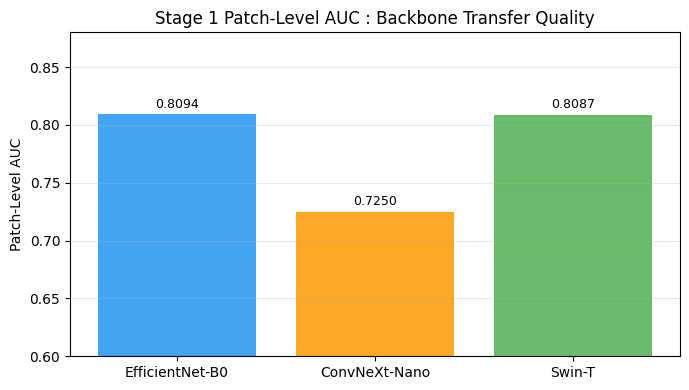

Saved nb06_stage1_patch_auc.png


In [7]:
# Bar chart for Stage 1 patch AUC comparison
# Shows backbone transfer learning quality before bag aggregation
fig, ax = plt.subplots(figsize=(7, 4))
patch_aucs = [results[n]["stage1_metrics"]["patch_auc"] for n in models]
bars = ax.bar(models, patch_aucs, color=colors, alpha=0.85)
for bar, val in zip(bars, patch_aucs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f"{val:.4f}", ha='center', va='bottom', fontsize=9)
ax.set_ylim(0.60, 0.88)
ax.set_ylabel("Patch-Level AUC")
ax.set_title("Stage 1 Patch-Level AUC : Backbone Transfer Quality")
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "nb06_stage1_patch_auc.png", dpi=150)
plt.show()
print("Saved nb06_stage1_patch_auc.png")

## 6. Calibrated Threshold Comparison
Each model's optimal threshold reflects how it distributes 
prediction probabilities. EfficientNet-B0 (0.988) clusters 
probabilities near 1.0; Swin-T (0.364) spreads them more evenly; 
ConvNeXt-Nano (0.581) sits near the default. These differences 
are a property of each backbone's output distribution, not 
an indication of model quality.

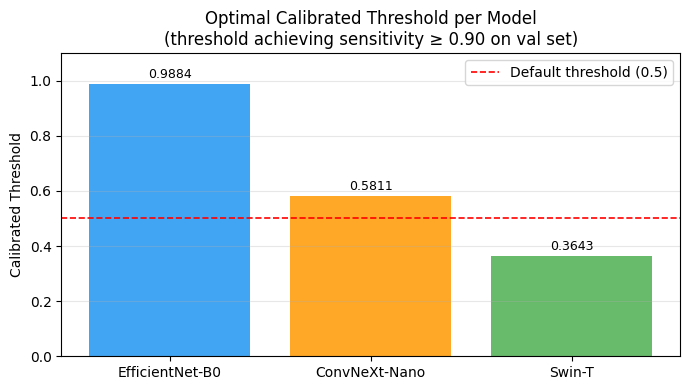

Saved nb06_threshold_comparison.png


In [8]:
# Threshold comparison plot
# Shows how differently each model distributes its probabilities
thresholds = [results[n]["optimal_threshold"] for n in models]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(models, thresholds, color=colors, alpha=0.85)
for bar, val in zip(bars, thresholds):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.4f}", ha='center', va='bottom', fontsize=9)
ax.axhline(0.5, color='red', linestyle='--', lw=1.2,
           label="Default threshold (0.5)")
ax.set_ylim(0, 1.1)
ax.set_ylabel("Calibrated Threshold")
ax.set_title("Optimal Calibrated Threshold per Model\n"
             "(threshold achieving sensitivity ≥ 0.90 on val set)")
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "nb06_threshold_comparison.png", dpi=150)
plt.show()
print("Saved nb06_threshold_comparison.png")

## 7. Calibration Quality : ECE
Expected Calibration Error measures how well predicted probabilities 
match actual outcome frequencies. Lower is better. Swin-T (0.0066) 
is the best calibrated; ConvNeXt-Nano (0.0380) the worst. 
Well-calibrated models are preferable in clinical deployment 
where probability outputs are used for decision support.

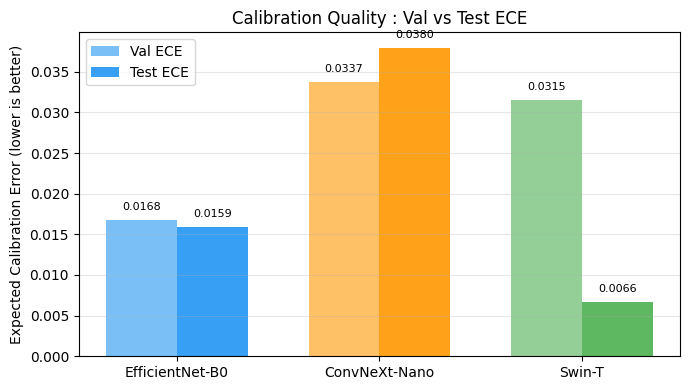

Saved nb06_ece_comparison.png


In [9]:
# ECE comparison (calibration quality)
# Lower ECE = better calibrated probability outputs
test_eces = [results[n]["test_metrics"]["ece"] for n in models]
val_eces  = [results[n]["val_metrics_cal"]["ece"] for n in models]

x     = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width/2, val_eces,  width, label="Val ECE",  color=colors, alpha=0.6)
ax.bar(x + width/2, test_eces, width, label="Test ECE", color=colors, alpha=0.9)
for i, (v, t) in enumerate(zip(val_eces, test_eces)):
    ax.text(i - width/2, v + 0.001, f"{v:.4f}",
            ha='center', va='bottom', fontsize=8)
    ax.text(i + width/2, t + 0.001, f"{t:.4f}",
            ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel("Expected Calibration Error (lower is better)")
ax.set_title("Calibration Quality : Val vs Test ECE")
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "nb06_ece_comparison.png", dpi=150)
plt.show()
print("Saved nb06_ece_comparison.png")

## 8. Hyperparameter Comparison
Documents the deliberate structural differences between models. 
Swin-T uses lower LR (1e-4), AdamW, more epochs (25), and more 
patience (7), all standard adjustments for transformer training. 
NB03 and NB04 are otherwise identical in setup.

In [10]:
# Hyperparameter comparison table
# Documents structural differences between models
print("\n── Hyperparameter Comparison ──")
hp_rows = [
    ("LR Stage 1",   "lr_stage1"),
    ("LR Stage 2",   "lr_s2_head"),
    ("Epochs S1",    "epochs_s1"),
    ("Epochs S2",    "epochs_s2"),
    ("Batch size",   "bs_stage1"),
    ("Patience S1",  "patience_s1"),
    ("Patience S2",  "patience_s2"),
]
header = f"{'Parameter':<20}" + "".join(f"{m:>{col_width}}" for m in models)
print(header)
print("-" * (20 + col_width * len(models)))
for label, key in hp_rows:
    row = f"{label:<20}"
    for name in models:
        val = results[name]["hyperparameters"][key]
        row += f"{str(val):>{col_width}}"
    print(row)


── Hyperparameter Comparison ──
Parameter                EfficientNet-B0       ConvNeXt-Nano              Swin-T
--------------------------------------------------------------------------------
LR Stage 1                         0.001               0.001              0.0001
LR Stage 2                        0.0001              0.0001              0.0001
Epochs S1                             15                  15                  25
Epochs S2                             30                  30                  30
Batch size                           128                 128                 128
Patience S1                            5                   5                   7
Patience S2                            7                   7                   7


## 9. Literature Benchmark Comparison
Contextual positioning against published results on DDSM/CBIS-DDSM. 
These are not direct equivalences as evaluation units, datasets, and 
architectures differ. The table documents what prior work reported 
and where this pipeline sits relative to it.

Key caveats:
- Literature figures are image-level; mine is patient/bag-level
- No prior work uses an identical ABMIL pipeline on CBIS-DDSM
- Jaamour et al. (2022) on the same dataset (CBIS-DDSM) report 
  67.4% accuracy but even the weakest model (ConvNeXt-Nano) exceeds this

In [16]:
print("\n── Literature Benchmark Comparison ──\n")
benchmarks = [
    {
        "reference"   : "Nature Sci. Reports 2025 (CNN+BiLSTM+EffNet-B0)",
        "dataset"     : "CBIS-DDSM + MIAS",
        "metric"      : "Accuracy",
        "value"       : 0.992,
        "sensitivity" : None,   # not reported as standalone metric
        "specificity" : None,
        "auc"         : None,
        "f1"          : None,
        "eval_unit"   : "Image-level",
        "eval_strategy": "Held-out test set",
        "notes"       : "Current SOTA on CBIS-DDSM. Bi-LSTM over full image, not patch-based MIL. Accuracy reported only.",
    },
    {
        "reference"   : "BreastNet-SVM IEEE Access 2023",
        "dataset"     : "DDSM",
        "metric"      : "Accuracy",
        "value"       : 0.9916,
        "sensitivity" : 0.9713,
        "specificity" : 0.9930,
        "auc"         : None,
        "f1"          : None,
        "eval_unit"   : "Image-level",
        "eval_strategy": "Held-out test set",
        "notes"       : "CNN+SVM hybrid. Best result with SGD at 32x32 input. Strong sensitivity reported.",
    },
    {
        "reference"   : "Divide & Conquer PLOS ONE 2022",
        "dataset"     : "CBIS-DDSM",
        "metric"      : "Accuracy + F1",
        "value"       : 0.674,   
        "sensitivity" : None,
        "specificity" : None,
        "auc"         : None,
        "f1"          : None,
        "eval_unit"   : "Image-level (whole image)",
        "eval_strategy": "Held-out test set",
        "notes"       : "MobileNetV2 outperforms VGG19/ResNet50/InceptionV3/DenseNet121 on CBIS-DDSM",
    },
    {
        "reference"   : "Fine-tuned ViT arXiv 2024",
        "dataset"     : "Mendeley mammography",
        "metric"      : "Accuracy",
        "value"       : 0.9933,
        "sensitivity" : 0.96,
        "specificity" : 1.00,
        "auc"         : 0.9997,
        "f1"          : None,
        "eval_unit"   : "Image-level",
        "eval_strategy": "Held-out test set",
        "notes"       : "Different dataset hence not directly comparable. Included for ViT context only.",
    },
]

# Print benchmark table
col_w = [52, 24, 12, 14, 14, 36]
headers = ["Reference", "Dataset", "Accuracy", "Sensitivity", "Specificity", "Eval unit"]
header_str = "".join(f"{h:<{w}}" for h, w in zip(headers, col_w))
print(header_str)
print("-" * sum(col_w))

for b in benchmarks:
    acc  = f"{b['value']:.4f}" if b["value"]  is not None else "—"
    sens = f"{b['sensitivity']:.4f}" if b["sensitivity"] is not None else "—"
    spec = f"{b['specificity']:.4f}" if b["specificity"] is not None else "—"
    row  = (f"{b['reference']:<{col_w[0]}}"
            f"{b['dataset']:<{col_w[1]}}"
            f"{acc:<{col_w[2]}}"
            f"{sens:<{col_w[3]}}"
            f"{spec:<{col_w[4]}}"
            f"{b['eval_unit']:<{col_w[5]}}")
    print(row)

print("-" * sum(col_w))


── Literature Benchmark Comparison ──

Reference                                           Dataset                 Accuracy    Sensitivity   Specificity   Eval unit                           
--------------------------------------------------------------------------------------------------------------------------------------------------------
Nature Sci. Reports 2025 (CNN+BiLSTM+EffNet-B0)     CBIS-DDSM + MIAS        0.9920      —             —             Image-level                         
BreastNet-SVM IEEE Access 2023                      DDSM                    0.9916      0.9713        0.9930        Image-level                         
Divide & Conquer PLOS ONE 2022                      CBIS-DDSM               0.6740      —             —             Image-level (whole image)           
Fine-tuned ViT arXiv 2024                           Mendeley mammography    0.9933      0.9600        1.0000        Image-level                         
------------------------------------------

### 9b. This Pipeline's Results for Direct Comparison

In [12]:
# Results for direct juxtaposition
print("\n This Project which has ABMIL Pipeline (CBIS-DDSM, Patient-level split) \n")

our_results = [
    ("EfficientNet-B0", results["EfficientNet-B0"]),
    ("ConvNeXt-Nano",   results["ConvNeXt-Nano"]),
    ("Swin-T",          results["Swin-T"]),
]

col_w2 = [20, 10, 10, 14, 14, 10, 10]
headers2 = ["Model", "Test AUC", "Test F1",
            "Sensitivity", "Specificity", "FPR", "ECE"]
print("".join(f"{h:<{w}}" for h, w in zip(headers2, col_w2)))
print("-" * sum(col_w2))

for name, r in our_results:
    tm = r["test_metrics"]
    print(f"{name:<20}"
          f"{tm['auc']:<10.4f}"
          f"{tm['f1']:<10.4f}"
          f"{tm['sensitivity']:<14.4f}"
          f"{tm['specificity']:<14.4f}"
          f"{tm['fpr']:<10.4f}"
          f"{tm['ece']:<10.4f}")

print("-" * sum(col_w2))
print("\nEval unit     : Patient/bag-level (MIL aggregation)")
print("Eval strategy : Patient-level held-out test set")
print("Threshold     : Calibrated per model on val set (sensitivity >= 0.90)")


 This Project which has ABMIL Pipeline (CBIS-DDSM, Patient-level split) 

Model               Test AUC  Test F1   Sensitivity   Specificity   FPR       ECE       
----------------------------------------------------------------------------------------
EfficientNet-B0     0.9996    0.9831    0.9864        0.9870        0.0130    0.0159    
ConvNeXt-Nano       0.9748    0.9141    0.9048        0.9524        0.0476    0.0380    
Swin-T              1.0000    0.9800    1.0000        0.9740        0.0260    0.0066    
----------------------------------------------------------------------------------------

Eval unit     : Patient/bag-level (MIL aggregation)
Eval strategy : Patient-level held-out test set
Threshold     : Calibrated per model on val set (sensitivity >= 0.90)


## 10. Save Comparison Summary
Export a flat JSON of key metrics for all three models  used 
in NB07 (Optuna tuning) and NB08 (stacking ensemble).

In [13]:
# Save comparison summary as JSON for use in later notebooks
summary = {}
for name, r in results.items():
    summary[name] = {
        "feat_dim"          : r["feat_dim"],
        "optimal_threshold" : r["optimal_threshold"],
        "stage1_patch_auc"  : r["stage1_metrics"]["patch_auc"],
        "val_auc"           : r["val_metrics_cal"]["auc"],
        "val_f1"            : r["val_metrics_cal"]["f1"],
        "val_sensitivity"   : r["val_metrics_cal"]["sensitivity"],
        "val_fpr"           : r["val_metrics_cal"]["fpr"],
        "val_ece"           : r["val_metrics_cal"]["ece"],
        "test_auc"          : r["test_metrics"]["auc"],
        "test_f1"           : r["test_metrics"]["f1"],
        "test_sensitivity"  : r["test_metrics"]["sensitivity"],
        "test_specificity"  : r["test_metrics"]["specificity"],
        "test_fpr"          : r["test_metrics"]["fpr"],
        "test_ece"          : r["test_metrics"]["ece"],
    }

with open(OUT / "nb06_baseline_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Saved: nb06_baseline_summary.json")

Saved: nb06_baseline_summary.json


## 11. Final Ranking and Model Selection
Rankings across AUC, F1, ECE, and FPR determine which models 
proceed to hyperparameter tuning and ensemble. ConvNeXt-Nano 
is consistently weakest across all four metrics and is deferred. 
EfficientNet-B0 and Swin-T proceed to NB07/NB08.

In [14]:
# Final ranking printout
print("\n" + "=" * 55)
print("  NB06 — BASELINE COMPARISON SUMMARY")
print("=" * 55)

print("\n  Ranking by test AUC:")
ranked = sorted(models,
                key=lambda n: results[n]["test_metrics"]["auc"],
                reverse=True)
for i, name in enumerate(ranked, 1):
    auc = results[name]["test_metrics"]["auc"]
    print(f"    {i}. {name:<20} test AUC = {auc:.4f}")

print("\n  Ranking by test F1:")
ranked_f1 = sorted(models,
                   key=lambda n: results[n]["test_metrics"]["f1"],
                   reverse=True)
for i, name in enumerate(ranked_f1, 1):
    f1 = results[name]["test_metrics"]["f1"]
    print(f"    {i}. {name:<20} test F1  = {f1:.4f}")

print("\n  Ranking by test ECE (lower is better):")
ranked_ece = sorted(models,
                    key=lambda n: results[n]["test_metrics"]["ece"])
for i, name in enumerate(ranked_ece, 1):
    ece = results[name]["test_metrics"]["ece"]
    print(f"    {i}. {name:<20} test ECE = {ece:.4f}")

print("\n  Ranking by test FPR (lower is better):")
ranked_fpr = sorted(models,
                    key=lambda n: results[n]["test_metrics"]["fpr"])
for i, name in enumerate(ranked_fpr, 1):
    fpr = results[name]["test_metrics"]["fpr"]
    print(f"    {i}. {name:<20} test FPR = {fpr:.4f}")

print("\n  Overall: EfficientNet-B0 and Swin-T selected for")
print("  NB07 Optuna tuning and NB08 stacking ensemble.")
print("  ConvNeXt-Nano deferred as weaker on all metrics.")
print("=" * 55)


  NB06 — BASELINE COMPARISON SUMMARY

  Ranking by test AUC:
    1. Swin-T               test AUC = 1.0000
    2. EfficientNet-B0      test AUC = 0.9996
    3. ConvNeXt-Nano        test AUC = 0.9748

  Ranking by test F1:
    1. EfficientNet-B0      test F1  = 0.9831
    2. Swin-T               test F1  = 0.9800
    3. ConvNeXt-Nano        test F1  = 0.9141

  Ranking by test ECE (lower is better):
    1. Swin-T               test ECE = 0.0066
    2. EfficientNet-B0      test ECE = 0.0159
    3. ConvNeXt-Nano        test ECE = 0.0380

  Ranking by test FPR (lower is better):
    1. EfficientNet-B0      test FPR = 0.0130
    2. Swin-T               test FPR = 0.0260
    3. ConvNeXt-Nano        test FPR = 0.0476

  Overall: EfficientNet-B0 and Swin-T selected for
  NB07 Optuna tuning and NB08 stacking ensemble.
  ConvNeXt-Nano deferred as weaker on all metrics.
